In [25]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

In [17]:
# Set parameters
image_size = (256, 256)  # Resize all images to this size
batch_size = 8
base_path = "/home/umar_ali/seml_2025/data/3_axes_spectrograms_odd"

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2,  # Reserve 20% of the data for validation
)

train_generator = train_datagen.flow_from_directory(
    base_path,
    target_size=(image_size[0], image_size[1]),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle = False
)

# Create validation data generator
validation_generator = train_datagen.flow_from_directory(
    base_path,
    target_size=(image_size[0], image_size[1]),  # Resize images to the target size
    batch_size=batch_size,
    class_mode='binary',  # Binary classification
    subset='validation',  # This will use the validation subset
    shuffle = False
)

print("Class indices for training data:", train_generator.class_indices)
print("Class indices for validation data:", validation_generator.class_indices)

# Load a batch of images and labels
images, labels = next(train_generator)

# Print labels for this batch
print("Labels for the first batch:", labels)

sample_batch = next(train_generator)
print(sample_batch[0].shape)

print("Samples in training data:", train_generator.samples)
print("Samples in validation data:", validation_generator.samples)


Found 346 images belonging to 2 classes.


Found 86 images belonging to 2 classes.
Class indices for training data: {'class_0': 0, 'class_1': 1}
Class indices for validation data: {'class_0': 0, 'class_1': 1}
Labels for the first batch: [0. 0. 0. 0. 0. 0. 0. 0.]
(8, 256, 256, 3)
Samples in training data: 346
Samples in validation data: 86


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile the model with a dynamic learning rate scheduler
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print(model.summary)

<bound method Model.summary of <Sequential name=sequential_3, built=True>>


In [20]:
# Training with callbacks
history = model.fit(train_generator, validation_data=validation_generator, epochs=84)

Epoch 1/84


/home/umar_ali/SEML/virtual_folder/venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - accuracy: 0.4860 - loss: 0.6983 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/84
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 288ms/step - accuracy: 0.6384 - loss: 0.6825 - val_accuracy: 0.5116 - val_loss: 0.6925
Epoch 3/84
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 297ms/step - accuracy: 0.7016 - loss: 0.6680 - val_accuracy: 0.4884 - val_loss: 0.6926
Epoch 4/84
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 297ms/step - accuracy: 0.5477 - loss: 0.6723 - val_accuracy: 0.5000 - val_loss: 0.6916
Epoch 5/84
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 302ms/step - accuracy: 0.6545 - loss: 0.6545 - val_accuracy: 0.5349 - val_loss: 0.6907
Epoch 6/84
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 305ms/step - accuracy: 0.6607 - loss: 0.6640 - val_accuracy: 0.5000 - val_loss: 0.6887
Epoch 7/84
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 302ms/step - accuracy: 0.5893 - loss: 0.6737 - val_accuracy: 0.5116 - val_loss: 0.6926
Epoch 8/84
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 307ms/step - accuracy: 0.6458 - loss: 0.6298 - val_accuracy: 0.500

In [21]:
# Evaluate the model
test_loss, test_acc = model.evaluate(validation_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4185 - loss: 1.0189
Test Accuracy: 66.28%


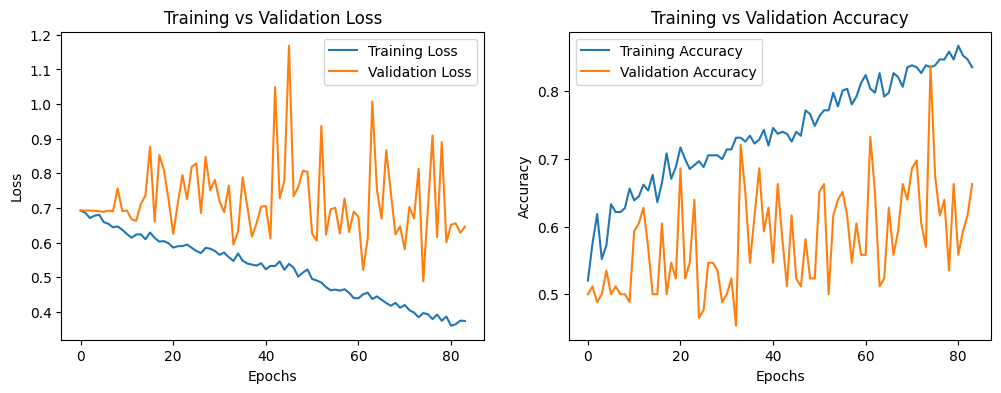

In [22]:
# Plot training & validation loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.37      0.52        43
           1       0.60      0.95      0.74        43

    accuracy                           0.66        86
   macro avg       0.75      0.66      0.63        86
weighted avg       0.75      0.66      0.63        86

Precision: 0.6029
Recall: 0.9535
F1-Score: 0.7387
ROC AUC: 0.6628


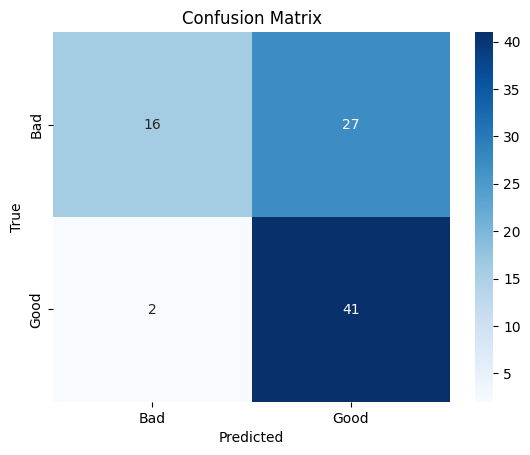

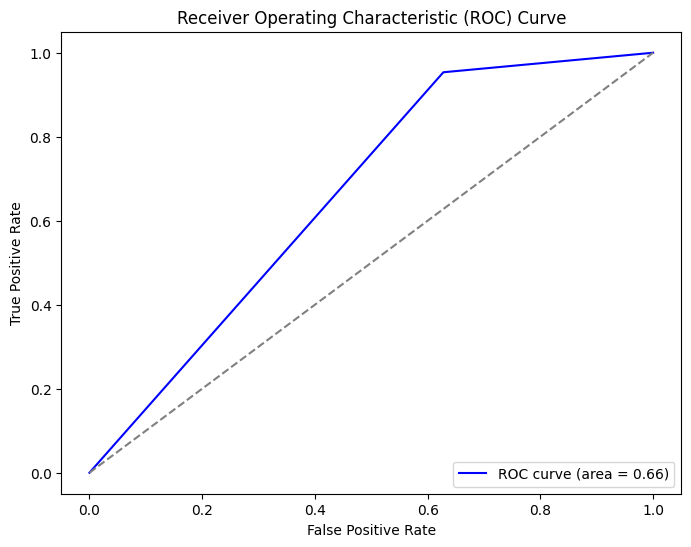

In [24]:
# Get the true labels and predictions from the validation generator
true_labels = validation_generator.classes  # Get the actual labels
predictions = model.predict(validation_generator, verbose=1)  # Get the model's predictions

# Convert probabilities to binary labels (0 or 1) based on a threshold of 0.5
predictions = (predictions >= 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predictions)

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report

# Get the true labels and predictions from the validation generator
true_labels = validation_generator.classes  # Get the actual labels
predictions = model.predict(validation_generator, verbose=1)  # Get the model's predictions

# Convert probabilities to binary labels (0 or 1) based on a threshold of 0.5
predictions = (predictions >= 0.5).astype(int)

# Precision, Recall, F1-Score
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)

# ROC AUC score (Area Under the Curve for Receiver Operating Characteristic)
roc_auc = roc_auc_score(true_labels, predictions)

# Print the classification report (includes precision, recall, f1-score, and support)
print("Classification Report:")
print(classification_report(true_labels, predictions))

# Print individual metrics
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Optionally, display it more clearly (for binary classification)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Calculate ROC curve
fpr, tpr, _ = roc_curve(true_labels, predictions)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()